# 04 — Train the MLP surrogate

The target is the Monte Carlo price. We split the scenarios, normalize inputs using training statistics only, train an MLP, and compare its prices against held-out Monte Carlo prices.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn

torch.manual_seed(42)
data = pd.read_csv(Path('artifacts') / 'labeled_scenarios.csv')
feature_names = [c for c in data.columns if c not in ['mc_price', 'mc_standard_error']]
X = data[feature_names].to_numpy(dtype=np.float32)
y = data['mc_price'].to_numpy(dtype=np.float32).reshape(-1, 1)

split_1 = int(0.70 * len(X))
split_2 = int(0.85 * len(X))
X_train, X_val, X_test = X[:split_1], X[split_1:split_2], X[split_2:]
y_train, y_val, y_test = y[:split_1], y[split_1:split_2], y[split_2:]

x_mean, x_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - x_mean) / x_std
X_val = (X_val - x_mean) / x_std
X_test = (X_test - x_mean) / x_std

X_train = torch.tensor(X_train)
X_val = torch.tensor(X_val)
X_test = torch.tensor(X_test)
y_train = torch.tensor(y_train)
y_val = torch.tensor(y_val)
y_test = torch.tensor(y_test)


In [6]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Softplus(),  # Option prices cannot be negative.
)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [7]:
for epoch in range(2_000):
    model.train()
    optimizer.zero_grad()
    train_loss = loss_fn(model(X_train), y_train)
    train_loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val), y_val)
        print(f'epoch {epoch:4d} | train MSE {train_loss.item():.4f} | val MSE {val_loss.item():.4f}')


epoch    0 | train MSE 176.8296 | val MSE 175.1726
epoch  200 | train MSE 2.6581 | val MSE 2.7574
epoch  400 | train MSE 1.2310 | val MSE 1.3132
epoch  600 | train MSE 0.6489 | val MSE 0.8176
epoch  800 | train MSE 0.4331 | val MSE 0.6285
epoch 1000 | train MSE 0.3113 | val MSE 0.5280
epoch 1200 | train MSE 0.2350 | val MSE 0.4782
epoch 1400 | train MSE 0.1926 | val MSE 0.4588
epoch 1600 | train MSE 0.1666 | val MSE 0.4547
epoch 1800 | train MSE 0.1464 | val MSE 0.4502


In [8]:
model.eval()
with torch.no_grad():
    prediction = model(X_test).numpy().ravel()
actual = y_test.numpy().ravel()
mae = np.mean(np.abs(prediction - actual))
rmse = np.sqrt(np.mean((prediction - actual) ** 2))
print(f'test MAE:  {mae:.4f}')
print(f'test RMSE: {rmse:.4f}')
pd.DataFrame({'actual_mc_price': actual, 'mlp_price': prediction}).head(10)


test MAE:  0.5289
test RMSE: 0.6472


,actual_mc_price,mlp_price
0,16.966196,17.560623
1,5.378214,5.510767
2,12.834008,13.008777
3,8.853312,8.541335
4,13.757598,13.709755
5,24.006462,24.755569
6,6.479654,7.191390
7,0.742953,1.433524
8,17.323225,16.772079
9,13.362702,13.354976


## Monte Carlo vs. MLP vs. Black–Scholes

Standard Black–Scholes is a single-asset model, so it cannot price our arithmetic basket exactly. Here we use a **moment-matched Black–Scholes approximation**: the five correlated assets are replaced by one lognormal asset with the same first two terminal-price moments. We then compare that approximation and the MLP with the same Monte Carlo test labels.

In [ ]:
from math import erf

def normal_cdf(x):
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def basket_black_scholes(row):
    # Approximate the arithmetic basket with a moment-matched lognormal asset.
    spots = row[[f'spot_{i}' for i in range(1, 6)]].to_numpy(dtype=float)
    vols = row[[f'vol_{i}' for i in range(1, 6)]].to_numpy(dtype=float)
    weights = np.full(5, 1 / 5)
    K, T, r, rho = row['strike'], row['maturity'], row['rate'], row['correlation']

    basket_spot = weights @ spots
    corr = np.full((5, 5), rho)
    np.fill_diagonal(corr, 1.0)

    weighted_spots = weights * spots
    covariance_growth = np.exp(corr * np.outer(vols, vols) * T)
    second_moment_ratio = (weighted_spots @ covariance_growth @ weighted_spots) / basket_spot**2
    basket_vol = np.sqrt(np.log(second_moment_ratio) / T)

    d1 = (np.log(basket_spot / K) + (r + 0.5 * basket_vol**2) * T) / (basket_vol * np.sqrt(T))
    d2 = d1 - basket_vol * np.sqrt(T)
    return basket_spot * normal_cdf(d1) - K * np.exp(-r * T) * normal_cdf(d2)

test_rows = data.iloc[split_2:]
black_scholes_price = test_rows.apply(basket_black_scholes, axis=1).to_numpy()
bs_mae = np.mean(np.abs(black_scholes_price - actual))
bs_rmse = np.sqrt(np.mean((black_scholes_price - actual) ** 2))

print(f'MLP MAE:            {mae:.4f}')
print(f'Black–Scholes MAE:  {bs_mae:.4f}')
print(f'MLP RMSE:           {rmse:.4f}')
print(f'Black–Scholes RMSE: {bs_rmse:.4f}')
pd.DataFrame({
    'monte_carlo_price': actual,
    'mlp_price': prediction,
    'basket_black_scholes_price': black_scholes_price,
}).head(10)


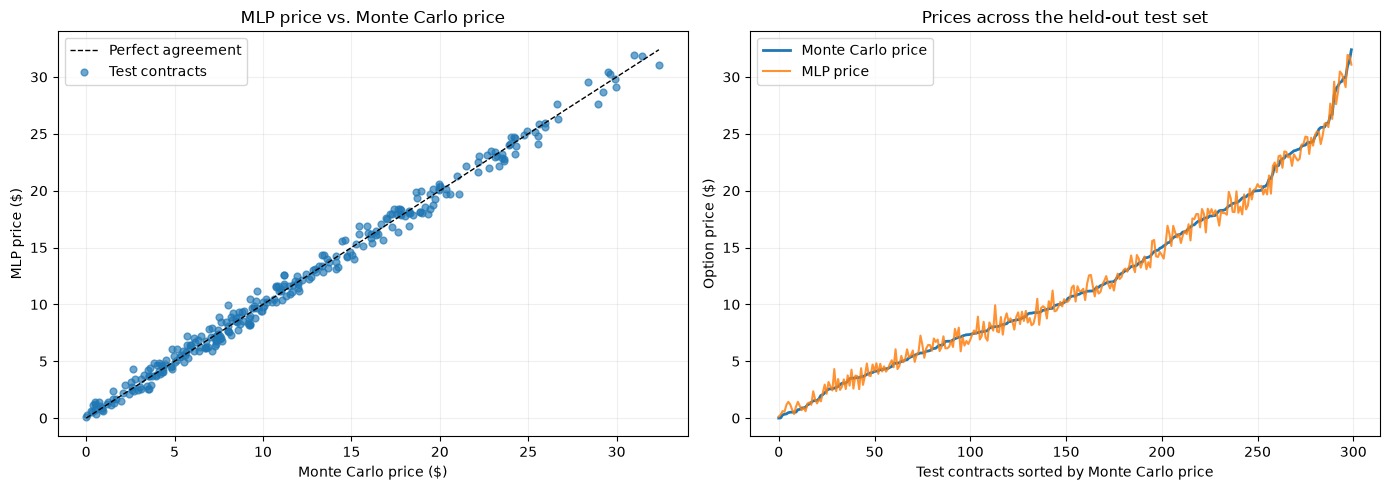

In [9]:
import matplotlib.pyplot as plt

price_min = min(actual.min(), prediction.min(), black_scholes_price.min())
price_max = max(actual.max(), prediction.max(), black_scholes_price.max())
order = np.argsort(actual)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot([price_min, price_max], [price_min, price_max], 'k--', linewidth=1, label='Perfect agreement')
axes[0].scatter(actual, prediction, alpha=0.65, s=24, label='MLP')
axes[0].scatter(actual, black_scholes_price, alpha=0.65, s=24, marker='x', label='Basket Black–Scholes')
axes[0].set_xlabel('Monte Carlo price ($)')
axes[0].set_ylabel('Model price ($)')
axes[0].set_title('Model prices vs. Monte Carlo price')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(actual[order], label='Monte Carlo price', linewidth=2)
axes[1].plot(prediction[order], label='MLP price', linewidth=1.5, alpha=0.85)
axes[1].plot(black_scholes_price[order], label='Basket Black–Scholes', linewidth=1.5, alpha=0.85)
axes[1].set_xlabel('Test contracts sorted by Monte Carlo price')
axes[1].set_ylabel('Option price ($)')
axes[1].set_title('Prices across the held-out test set')
axes[1].legend()
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()
